# 04 — Model Comparison

**Week 5 deliverable: California Property Close Price Prediction**

## Objective

Compare two nonlinear regression models with the Week 4 Linear Regression
baseline:

- Decision Tree Regressor
- Random Forest Regressor

The models are evaluated on the same held-out test month using R², MAE, and
RMSE. The best-performing model is selected for later feature-engineering work.


## 1. Imports and project paths


In [3]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.tree import DecisionTreeRegressor

PROCESSED_DIR = Path("processed")
RESULT_DIR = Path("results")
MODEL_DIR = Path("models")

RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Load the Week 3 data and Week 4 baseline result


In [39]:
required_files = [
    PROCESSED_DIR / "X_train_preprocessed.npz",
    PROCESSED_DIR / "X_test_preprocessed.npz",
    PROCESSED_DIR / "y_train_close_price.npy",
    PROCESSED_DIR / "y_test_close_price.npy",
    PROCESSED_DIR / "transformed_feature_names.csv",
    RESULT_DIR / "week4_baseline_results.csv",
]

missing_files = [
    str(path) for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Run Week 3 and Week 4 first. Missing files:\n"
        + "\n".join(missing_files)
    )

X_train = sparse.load_npz(
    PROCESSED_DIR / "X_train_preprocessed.npz"
)

X_test = sparse.load_npz(
    PROCESSED_DIR / "X_test_preprocessed.npz"
)

y_train = np.load(
    PROCESSED_DIR / "y_train_close_price.npy"
)

y_test = np.load(
    PROCESSED_DIR / "y_test_close_price.npy"
)

feature_names = pd.read_csv(
    PROCESSED_DIR / "transformed_feature_names.csv"
)["transformed_feature"].to_numpy()

week4_results = pd.read_csv(
    RESULT_DIR / "week4_baseline_results.csv"
)

linear_r2 = week4_results.loc[0, "TestR2"]
linear_mae = week4_results.loc[0, "TestMAE"]
linear_rmse = week4_results.loc[0, "TestRMSE"]

print("Training matrix:", X_train.shape)
print("Testing matrix: ", X_test.shape)
print(f"Week 4 Linear Regression R²: {linear_r2:.4f}")


Training matrix: (129972, 822)
Testing matrix:  (12024, 822)
Week 4 Linear Regression R²: 0.3520


## 3. Evaluation function


In [7]:
def evaluate_model(model_name, actual, predicted):
    predicted = np.clip(
        predicted,
        a_min=0,
        a_max=None
    )

    return {
        "Model": model_name,
        "Test R2": r2_score(
            actual,
            predicted
        ),
        "Test MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
    }


## 4. Train the Decision Tree model


In [9]:
decision_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=40,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)

decision_tree.fit(
    X_train,
    y_train
)

decision_tree_predictions = decision_tree.predict(
    X_test
)

decision_tree_result = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)

print(decision_tree_result)


{'Model': 'Decision Tree', 'Test R2': -0.8607730487640595, 'Test MAE': 221535.54982190853, 'Test RMSE': 2289044.4284011237}


## 5. Train the Random Forest model


In [11]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=5,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest.predict(
    X_test
)

random_forest_result = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)

print(random_forest_result)


{'Model': 'Random Forest', 'Test R2': -0.11176908272885555, 'Test MAE': 174360.3067241278, 'Test RMSE': 1769354.3362068906}


## 6. Compare all three models


In [13]:
comparison_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Test R2": linear_r2,
        "Test MAE": linear_mae,
        "Test RMSE": linear_rmse,
    },
    decision_tree_result,
    random_forest_result,
]).sort_values(
    "Test R2",
    ascending=False
).reset_index(drop=True)

display(
    comparison_df.style.format({
        "Test R2": "{:.4f}",
        "Test MAE": "${:,.0f}",
        "Test RMSE": "${:,.0f}",
    })
)

best_model_name = comparison_df.iloc[0]["Model"]
best_test_r2 = comparison_df.iloc[0]["Test R2"]

print("Best Week 5 model:", best_model_name)
print(f"Best test R²: {best_test_r2:.4f}")


,Model,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.3520,"$473,906","$1,350,821"
1,Random Forest,-0.1118,"$174,360","$1,769,354"
2,Decision Tree,-0.8608,"$221,536","$2,289,044"


Best Week 5 model: Linear Regression
Best test R²: 0.3520


## 7. Visualization: Test R² comparison


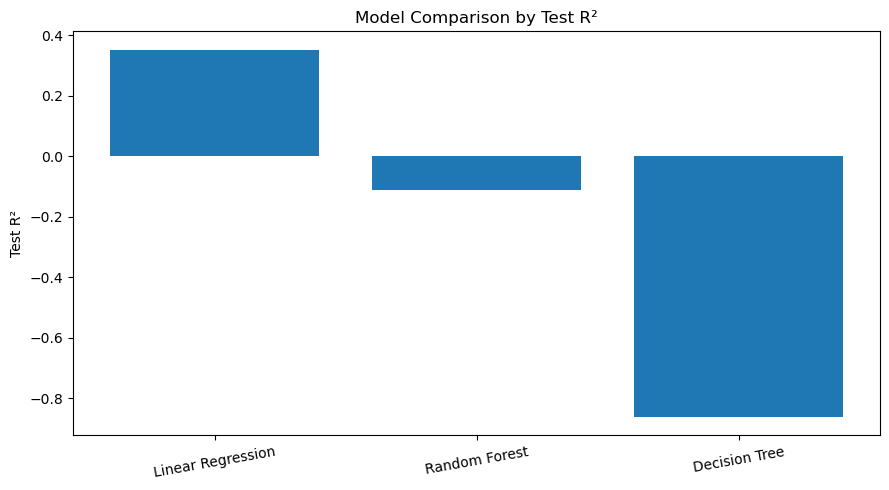

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Test R2"]
)

plt.ylabel("Test R²")
plt.title("Model Comparison by Test R²")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 8. Visualization: Random Forest feature importance

Feature importance shows which transformed variables contributed most to the
Random Forest predictions.


,Feature,Importance
5,numeric__OriginalListPrice,0.220361
3,numeric__LotSizeSquareFeet,0.174801
7,numeric__Longitude,0.151807
6,numeric__Latitude,0.110661
0,numeric__LivingArea,0.109057
4,numeric__YearBuilt,0.099228
1,numeric__BedroomsTotal,0.074386
2,numeric__BathroomsTotalInteger,0.011528
8,numeric__GarageSpaces,0.007295
450,categorical__PostalCode_91355,0.004614


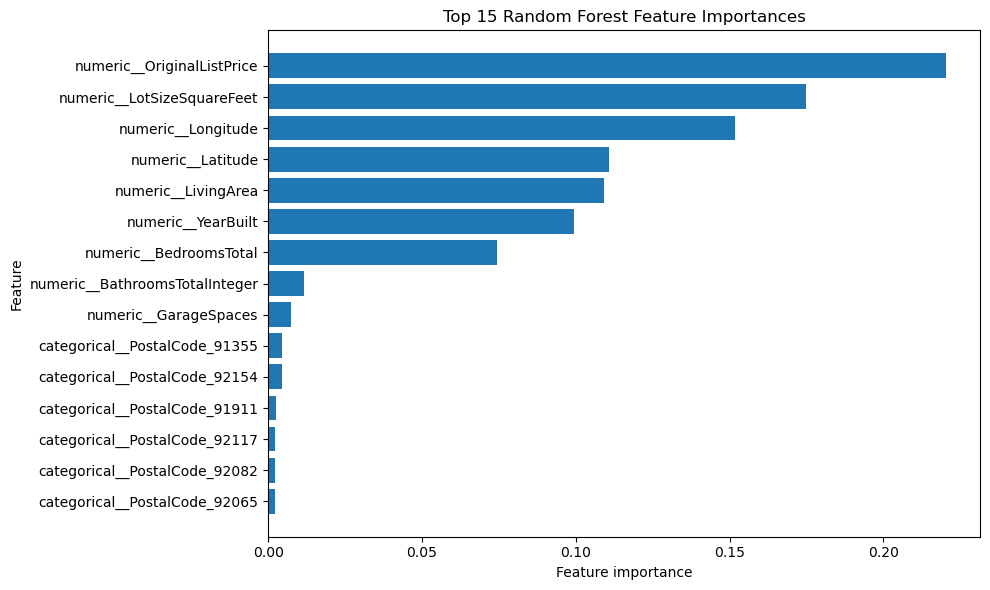

In [17]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_,
}).sort_values(
    "Importance",
    ascending=False
)

top_features = feature_importance.head(15)

display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## 9. Visualization: Random Forest actual vs predicted


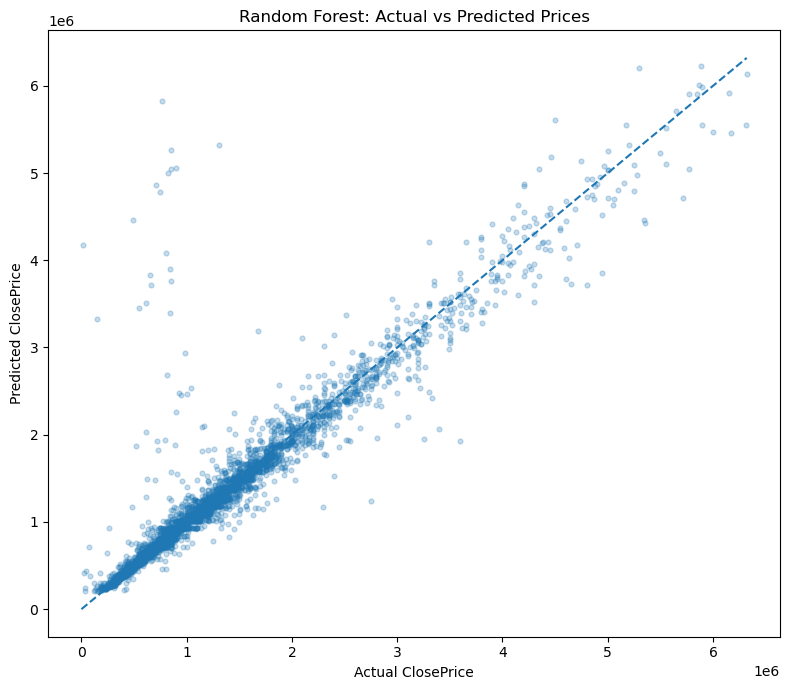

In [19]:
sample_size = min(
    5_000,
    len(y_test)
)

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_indices = rng.choice(
    len(y_test),
    size=sample_size,
    replace=False
)

actual_sample = y_test[
    sample_indices
]

predicted_sample = random_forest_predictions[
    sample_indices
]

plot_limit = np.quantile(
    np.concatenate([
        actual_sample,
        predicted_sample
    ]),
    0.99
)

plot_mask = (
    (actual_sample <= plot_limit)
    & (predicted_sample <= plot_limit)
)

plt.figure(figsize=(8, 7))
plt.scatter(
    actual_sample[plot_mask],
    predicted_sample[plot_mask],
    alpha=0.25,
    s=12
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--"
)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()


## 10. Visualization: Random Forest residual plot


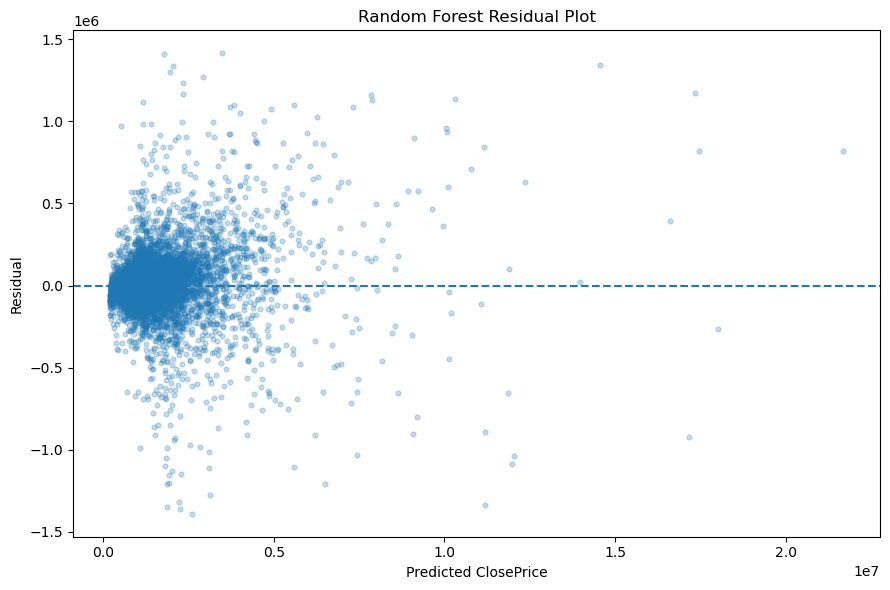

In [21]:
random_forest_residuals = (
    y_test - random_forest_predictions
)

residual_limit = np.quantile(
    np.abs(random_forest_residuals),
    0.99
)

residual_mask = (
    np.abs(random_forest_residuals) <= residual_limit
)

plt.figure(figsize=(9, 6))
plt.scatter(
    random_forest_predictions[residual_mask],
    random_forest_residuals[residual_mask],
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")
plt.tight_layout()
plt.show()


## 11. Model strengths and weaknesses

### Linear Regression

**Strengths**

- Fast and simple.
- Easy to interpret.
- Provides a clear baseline.

**Weaknesses**

- Assumes mostly linear relationships.
- Struggles with complex interactions.
- Can produce unrealistic negative predictions.

### Decision Tree

**Strengths**

- Captures nonlinear relationships.
- Easy to understand at shallow depth.
- Handles feature interactions naturally.

**Weaknesses**

- Can overfit the training data.
- Can be unstable when the data changes.
- Usually performs worse than an ensemble of trees.

### Random Forest

**Strengths**

- Combines many trees to improve stability.
- Captures nonlinear relationships and interactions.
- Usually generalizes better than a single Decision Tree.

**Weaknesses**

- Slower and more memory-intensive.
- Less interpretable than one tree.
- May still struggle with unusually expensive properties.


## 12. Save the models and comparison results


In [24]:
joblib.dump(
    decision_tree,
    MODEL_DIR / "week5_decision_tree.joblib"
)

joblib.dump(
    random_forest,
    MODEL_DIR / "week5_random_forest.joblib"
)

comparison_df.to_csv(
    RESULT_DIR / "week5_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    RESULT_DIR / "week5_random_forest_feature_importance.csv",
    index=False
)

print("Week 5 models and results saved.")


Week 5 models and results saved.


## 13. Summary

Three regression models were evaluated using the same training data and held-out
test month:

- Linear Regression (Week 4 baseline)
- Decision Tree Regressor
- Random Forest Regressor

### Results

| Model | Test R² | MAE | RMSE |
|--------|---------|---------|---------|
| Linear Regression | **0.3520** | **$473,906** | **$1,350,821** |
| Random Forest | **-0.1118** | **$174,360** | **$1,769,354** |
| Decision Tree | **-0.8608** | **$221,536** | **$2,289,044** |

The Linear Regression model achieved the highest test R² (0.3520) and therefore
performed better than both Decision Tree and Random Forest on the held-out test
dataset.

Although Random Forest produced a lower Mean Absolute Error than Linear
Regression, its negative R² indicates that it did not generalize well to the
test data. The Decision Tree model performed the worst, with the lowest R² and
the largest prediction errors.

The Random Forest feature importance plot identified the variables that
contributed most to the model's predictions, while the Actual vs Predicted and
Residual plots helped visualize the prediction accuracy and error distribution.

Based on the evaluation results, **Linear Regression remains the best-performing
model for the current preprocessing pipeline** and will be used as the baseline
for future improvements. In Week 6, additional feature engineering and model
refinement will be explored to improve prediction accuracy.

## Week 5 requirement checklist

- [x] Trained a Decision Tree Regressor
- [x] Trained a Random Forest Regressor
- [x] Compared both models with the Week 4 baseline
- [x] Evaluated test R²
- [x] Documented model strengths and weaknesses
- [x] Created model-comparison visualization
- [x] Created Random Forest feature-importance visualization
- [x] Created Actual vs Predicted visualization
- [x] Created residual visualization
- [x] Saved the models and comparison results
